In [61]:
# QUANTIDADE DE VEÍCULOS RECUPERADOS POR MUNICÍPIO

# Importação das bibliotecas
import pandas
import matplotlib.pyplot as plt 

# Carregando o arquivo CSV usando pandas
df = pandas.read_csv(r'C:\Users\Aluno.SantaLuzia\Documents\Elaine\uc2\bases\03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='iso-8859-1')

# Seleção das colunas 'munic' e 'recuperacao_veiculos'
# Agrupamento dos dados por município
# Somando o total de veículos recuperados
# Ordenação dos resultados do menor para o maior
veicRec_agrMunic = (
    df.groupby('munic')['recuperacao_veiculos'].sum().reset_index().sort_values(by= 'recuperacao_veiculos', ascending=False)
)

# Exibindo os 10 municípios com maior número de veículos recuperados
veicRec_agrMunic.head(10)

,munic,recuperacao_veiculos
68,Rio de Janeiro,269057
23,Duque de Caxias,42959
78,São Gonçalo,39574
81,São João de Meriti,19341
50,Nova Iguaçu,17217
48,Niterói,15417
6,Belford Roxo,14164
13,Campos dos Goytacazes,5334
47,Nilópolis,5257
43,Mesquita,5000


In [62]:
# Comparando com o ranking de roubo de veículos

veicRoub_agrMunic = (
    df.groupby('munic')['roubo_veiculo'].sum().reset_index().sort_values(by= 'roubo_veiculo', ascending=False)
)

veicRoub_agrMunic.head(10)

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
6,Belford Roxo,22417
48,Niterói,21646
47,Nilópolis,11952
43,Mesquita,7825
27,Itaboraí,5914


1. Sim, existe.
2. Sim, lidera.

In [63]:
# ANÁLISE POR ANO

# Seleção das colunas 'ano' e 'recuperacao_veiculos'
# Agrupamento dos dados por ano
# Soma do total de veículos recuperados por ano
# Ordenação dos resultados
veicRec_agrAno = (
    df.groupby('ano')[['recuperacao_veiculos', 'roubo_veiculo']].sum().reset_index().sort_values(by='ano')
)

veicRec_agrAno

,ano,recuperacao_veiculos,roubo_veiculo
0,2003,29947,33531
1,2004,26522,32408
2,2005,26332,32690
3,2006,26073,34324
4,2007,24452,31490
5,2008,21060,27847
6,2009,19913,25036
7,2010,16568,20052
8,2011,16142,18773
9,2012,17446,22065


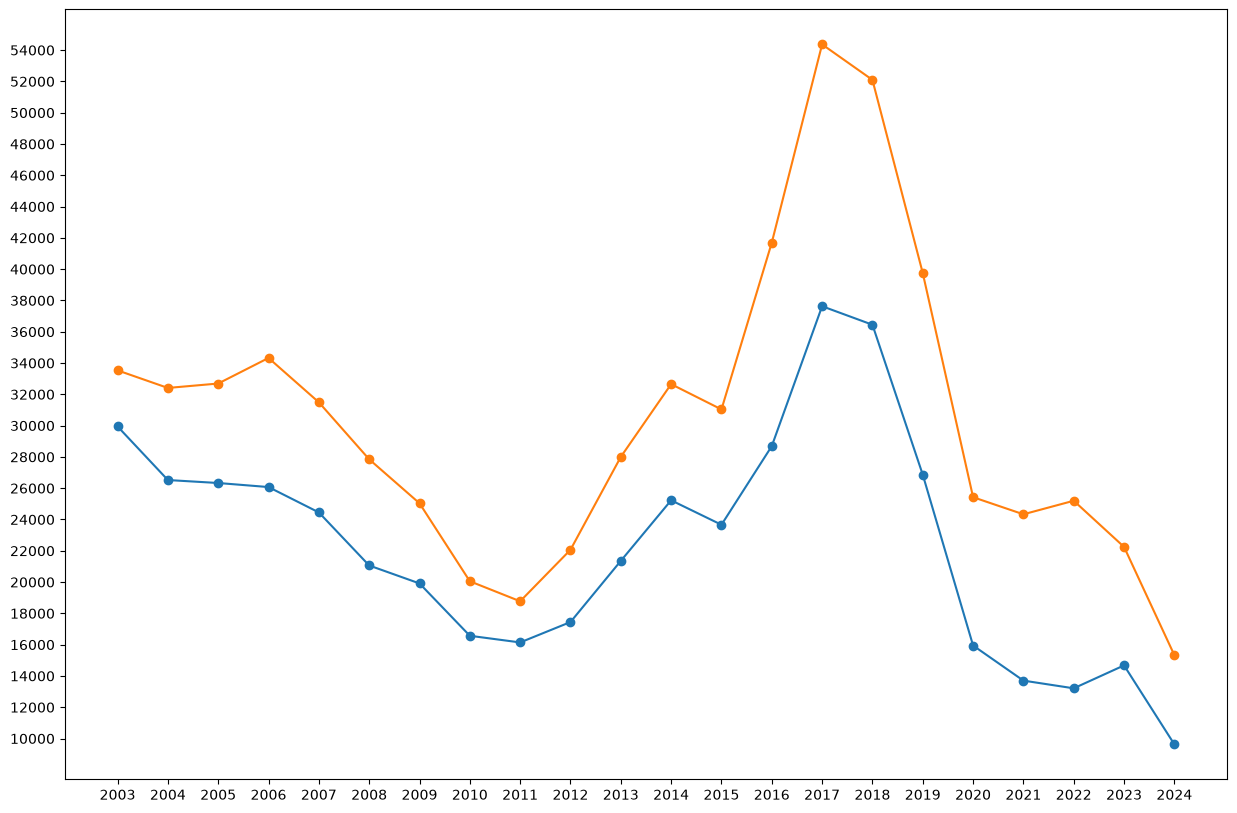

In [67]:
# Gráfico de Linha (Roubos e Recuperações / Ano)

plt.figure(figsize=(15, 10))
plt.plot(
    veicRec_agrAno['ano'].astype(str),
    veicRec_agrAno[['recuperacao_veiculos', 'roubo_veiculo']],
    marker='o'
)
plt.yticks(range(10000, 56000, 2000))

plt.show()

1. 2017
2. Sim. Entre 2003 e 2011 é possível perceber uma queda no número de veículos recuperados. Entre 2012 e 2017 há crescimento. De 2018 em diante uma tendencia de queda.
3. Com exceção dos anos de 2006 e 2023, sim, as ocilações do número de veículos recuperados acompanham o crescimento ou queda do número de roubos.

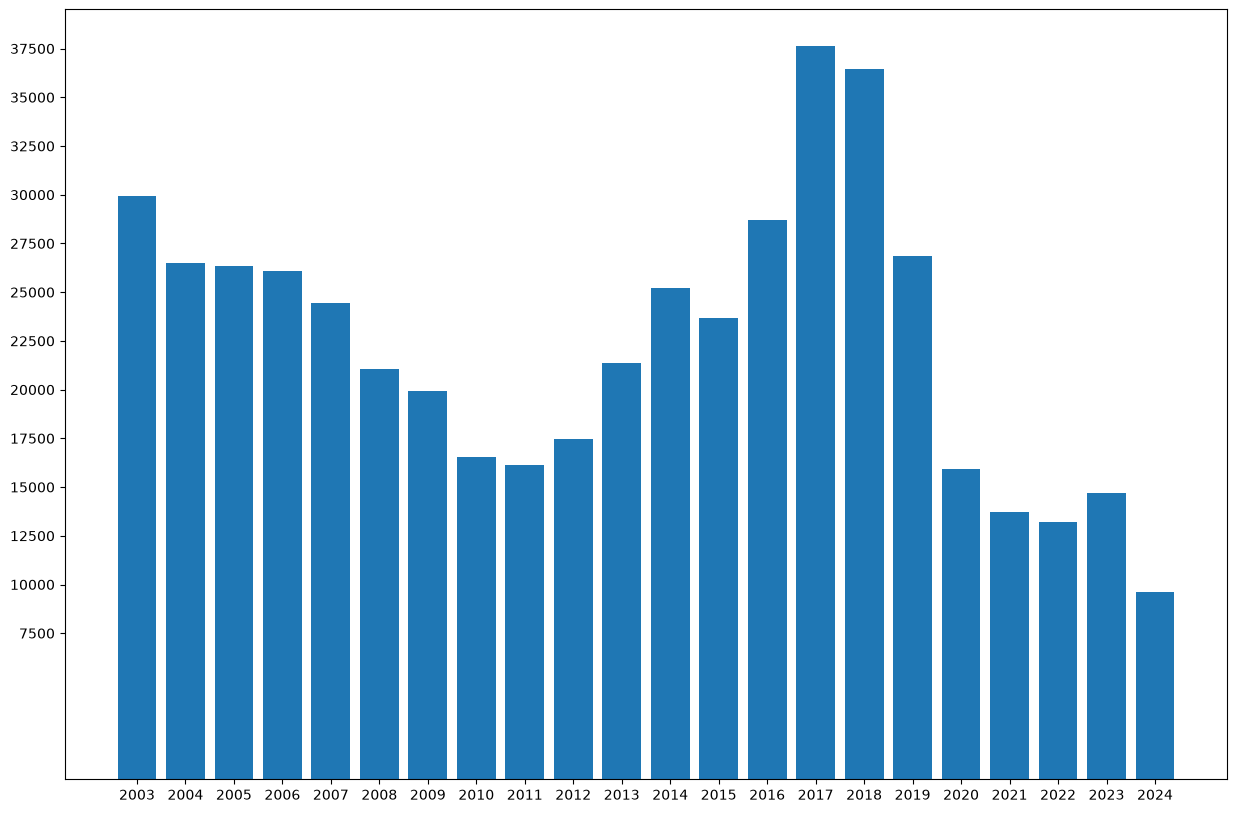

In [68]:
# Gráfico de Barras (Veículos recuperados / Ano)

plt.figure(figsize=(15,10))
plt.bar(
    veicRec_agrAno['ano'].astype(str),
    veicRec_agrAno['recuperacao_veiculos'], 
)

plt.xticks(rotation = 0)
plt.yticks(range(7500, 40000, 2500))
plt.show()



In [ ]:
# OUTLIERS

# Cálculos dos mínimos e máximos
min = veicRec_agrMunic['recuperacao_veiculos'].min()
max = veicRec_agrMunic['recuperacao_veiculos'].max()

# Cálculos dos limites Inferior e Superior
q3 = veicRec_agrMunic['recuperacao_veiculos'].quantile(0.75)
q1 = veicRec_agrMunic['recuperacao_veiculos'].quantile(0.25)
iqr = q3 - q1
li = q1 - 1.5*iqr
ls = q3 + 1.5*iqr

if (li > min):
    print ('LIMITE INFERIOR: ', li)
else:
    print ('LIMITE INFERIOR: ', min) 

if (ls < max):
    print ('LIMITE SUPERIOR: ', ls)
else:
    print ('LIMITE SUPERIOR: ', max) 

# DataFrame dos Outliers acima do limite superior 
outliers = veicRec_agrMunic[veicRec_agrMunic['recuperacao_veiculos'] > ls]

outliers

LIMITE INFERIOR:  24
LIMITE SUPERIOR:  3849.5


,munic,recuperacao_veiculos
68,Rio de Janeiro,269057
23,Duque de Caxias,42959
78,São Gonçalo,39574
81,São João de Meriti,19341
50,Nova Iguaçu,17217
48,Niterói,15417
6,Belford Roxo,14164
13,Campos dos Goytacazes,5334
47,Nilópolis,5257
43,Mesquita,5000


1. Sim, os anos de 2017 e 2018.
2. Sim, 2019 e 2020
3. O período de pandemia que diminuiu a quantidade de oportunidades de roubo; A diminuição do contingente de agentes atuando em recuperações.
4. Existem 11 municípios acima do limite superior (3849.5): Rio de Janeiro, Duque de Caxias, São Gonçalo, São João de Meriti, Nova Iguaçu, Niterói, Belford Roxo, Campos dos Goytacazes, Nilópolis, Mesquita e Itaboraí.